# HOUSING PRICE PREDICTION USING REGRESSION

The objective of this project is to develop a predictive model that estimates house prices based on key features such as area, number of bedrooms, bathrooms, and other property characteristics.

Accurate price prediction is important for:

- Real estate agents in setting competitive prices
- Property developers in planning investments
- Buyers in making informed purchasing decisions

# Objective 1: Split the dataset into training and testing sets.

In [4]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

In [5]:
#load the dataset
housing_df = pd.read_csv("Housing.csv")
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


The dataset has 13 columns/variables:-
  
    - price 
    - area
    - Number of bedrooms
    - Number of bathrooms
    - Number of stories
    - Number of parkings
    - Access to mainroad
    - Presence of guestroom, basement, hotwaterheating, airconditioning and prefarea
    - Furnishing status of the house ; furnished, semi-furnished or unfurnished.

There are no null values.

The data types in the dataset are integers and objects.

### Data Cleaning

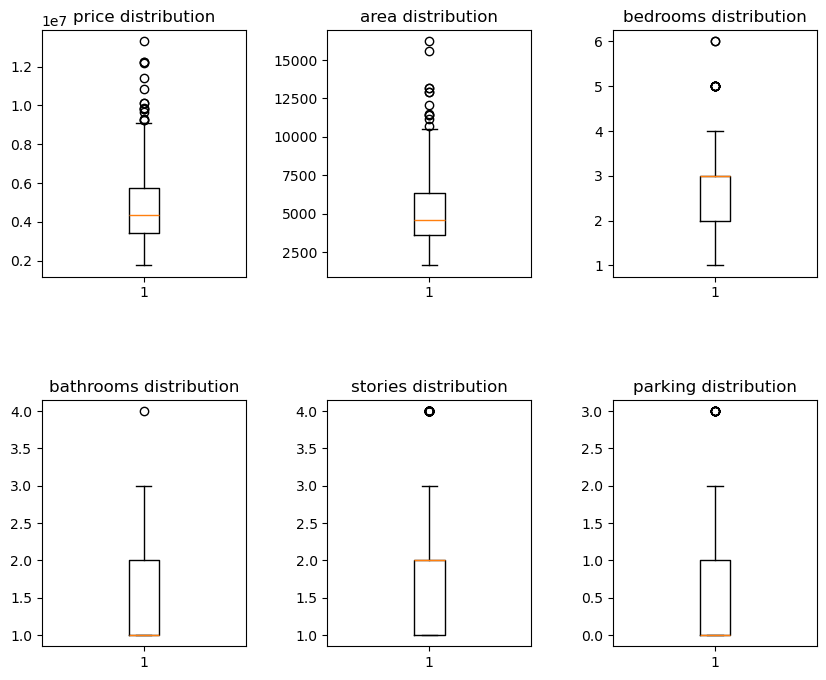

In [9]:
# Create boxplots
columns = housing_df.select_dtypes(include=[int, float])
# create subplots
fig, axs = plt.subplots(2, 3, figsize=(10, 8))
fig.subplots_adjust(hspace = 0.5, wspace=.4)
axs = axs.ravel()

for index, column in enumerate(columns):
    axs[index].boxplot(housing_df[column])
    axs[index].set_title(f"{column} distribution", fontsize=12)

**Handle outliers**

Outliers were handled using the IQR method, where extreme values were capped at the upper and lower whiskers to reduce their impact without removing observations

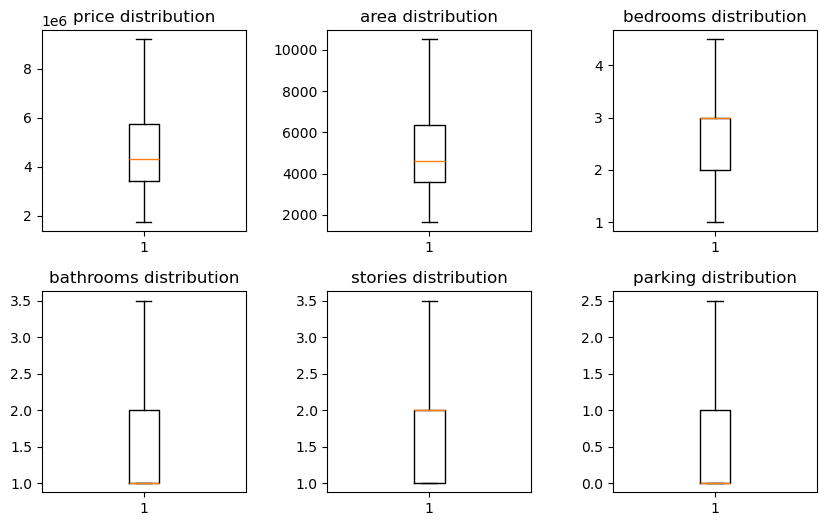

In [11]:
for col in columns:
    Q1 = housing_df[col].quantile(0.25)
    Q3 = housing_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR

    housing_df[col] = np.where(
        housing_df[col] > upper_whisker,
        upper_whisker,
        np.where(
            housing_df[col] < lower_whisker,
            lower_whisker,
            housing_df[col]
        )
    )

# Create boxplots
# create subplots
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
fig.subplots_adjust(hspace = 0.3, wspace=.4)
axs = axs.ravel()

for index, column in enumerate(columns):
    axs[index].boxplot(housing_df[column])
    axs[index].set_title(f"{column} distribution", fontsize=12)

### Explanatory Data Analysis

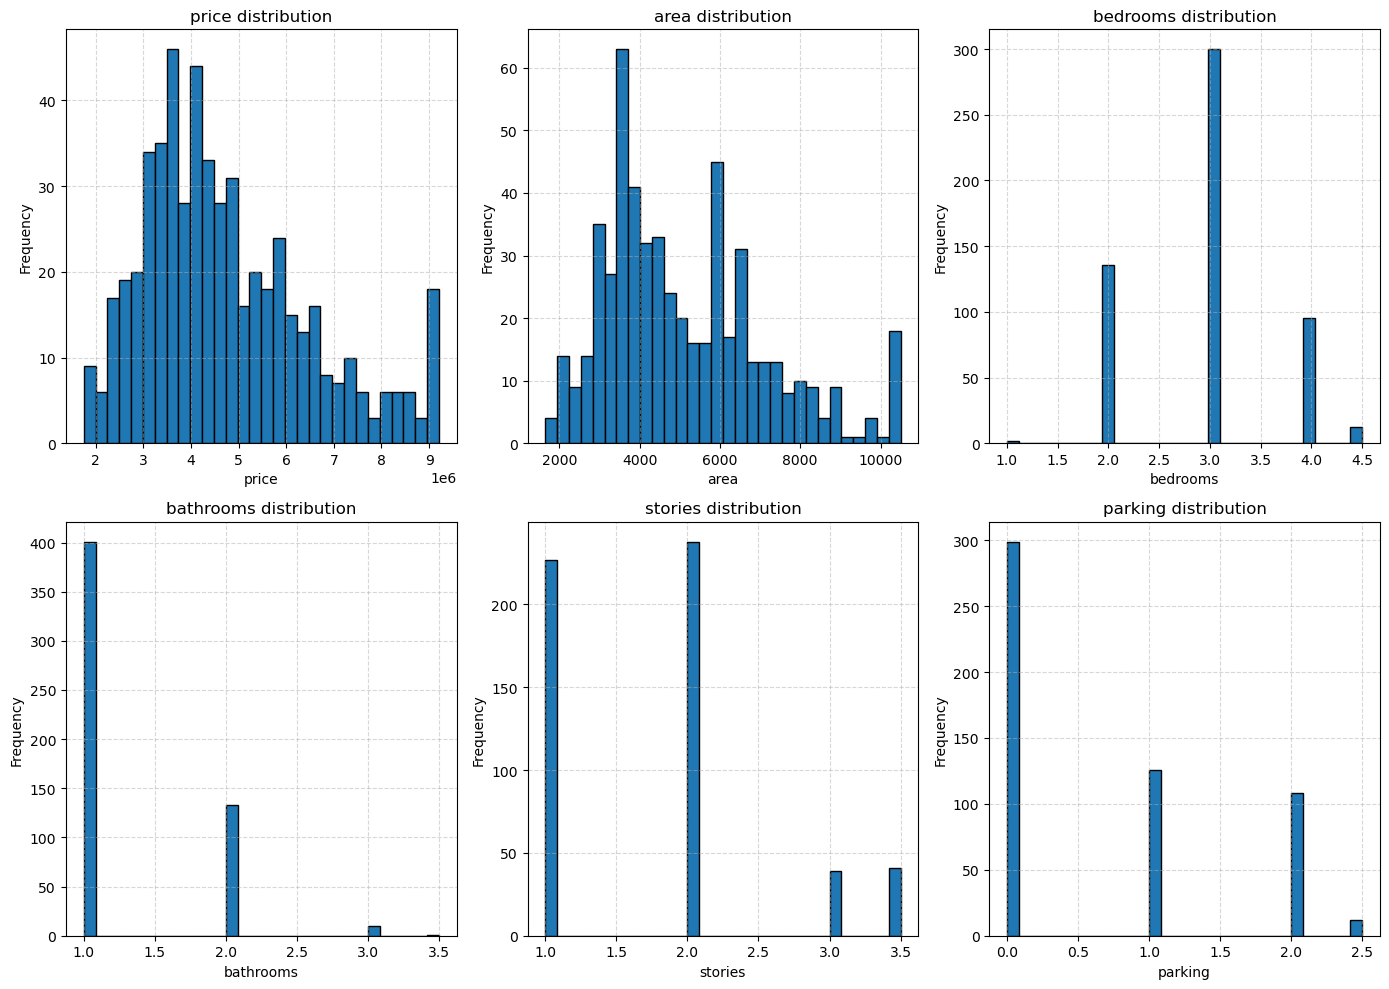

In [13]:
# Create histogram
columns = housing_df.select_dtypes(include=[int, float]).columns

fig, axs = plt.subplots(2, 3, figsize=(14, 10))
axs = axs.ravel()

for index, column in enumerate(columns):
    axs[index].hist(housing_df[column], bins=30, edgecolor='black')
    axs[index].set_title(f"{column} distribution", fontsize=12)
    axs[index].set_xlabel(column)
    axs[index].set_ylabel("Frequency")
    axs[index].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- Housing prices are not normally distributed. Extreme expensive houses are pulling the distribution to the right
- Area is right-skewed. Many houses have small–medium area. A few very large houses (outliers up to ~15,000+)
- Bedrooms are mostly concentrated around 2–4 bedrooms.They have an approximate normal bell shaped curve.
- Most houses: 1–2 bathrooms. Some outliers around 4+ bathrooms. Mostly 1-2 stories. Few extreme values (around 4+)
- Most houses have 0 parking spaces. Rare cases of 3+
- The housing dataset shows that price and area are highly right-skewed with a few extreme outliers, while most other features (bedrooms, bathrooms, stories, parking) are fairly concentrated within a narrow range. 
- Overall, the data is mostly made up of standard houses with a few luxury cases.
- These skewed distributions and outliers may affect model performance, so transformations or outlier handling may be needed to improve accuracy.

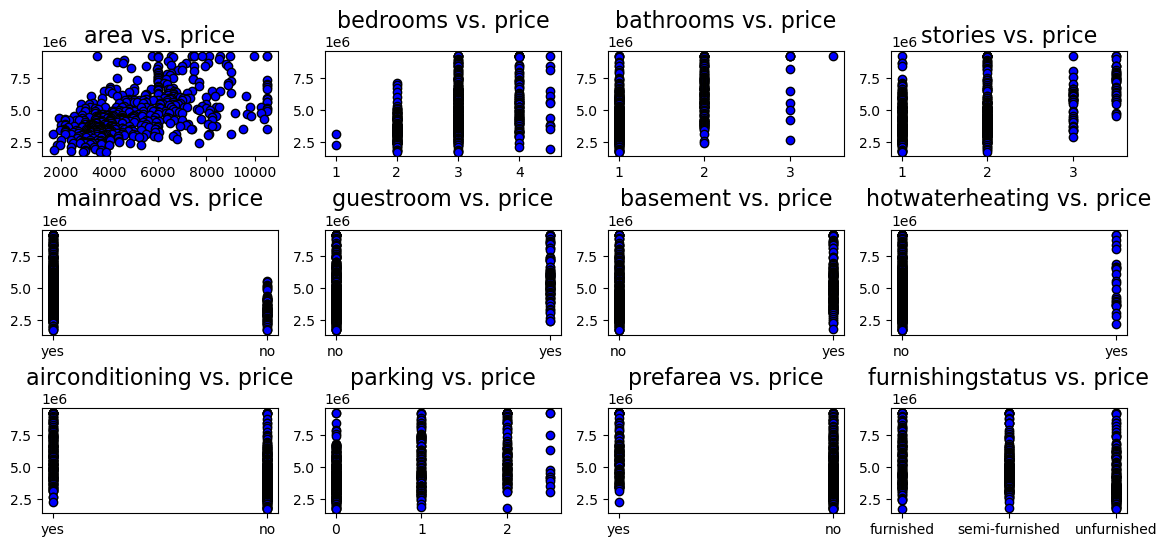

In [15]:
# Scatter plot
# Generate scatter plot between prices and other variables
fig, axs = plt.subplots(3,4, figsize=(14,6))
fig.subplots_adjust(hspace = 0.7, wspace=.2)
axs = axs.ravel()

for index, column in enumerate(housing_df.columns):
    axs[index-1].set_title("{} vs. price".format(column),fontsize=16)
    axs[index-1].scatter(x=housing_df[column],y=housing_df['price'],color='blue',edgecolor='k')

- House price and area has a very strong positive linear relationship where increase in area generally corresponds with increase in house price. The spread widens for larger areas indicating that beyond a certain point, other factors also affect the price.
- Bedrooms vs price have moderate to weak relationship with many bedrooms having higher prices but there are also some houses with more bedrooms but low prices indicating other factors are involved.
- Bathrooms vs price has a positive correlation which is steeper than bedrroms vs price
- More stories often correspond to higher price but not consistently — single-story luxury homes might also be expensive.
- Main road houses are more accessible and thus valued higher, though it depends on local preferences.
- Houses with basements generally have higher prices.
- Houses with hot water heating are generally more expensive.
- Homes with AC cluster at higher price ranges.
- The more the parking the higher the prices
- Houses in the preferred area are generally higher priced.
- Furnished houses are more priced.
- Larger homes with more amenities (like AC, basements, hot water heating, in preferred areas, and well-furnished) tend to have the highest prices.
- Some factors such as area and location show a more consistent effect, while others like bedrooms or stories show more variability.

<Axes: >

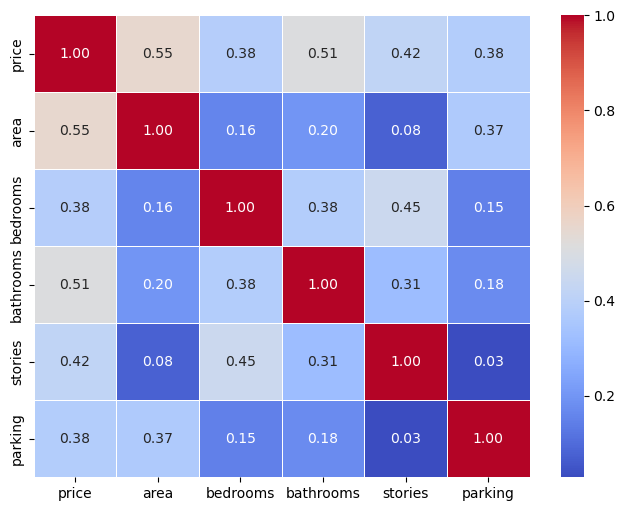

In [17]:
# get the correlation
correlation = housing_df[columns].corr()

# create a matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f" )

The correlation analysis shows:

- Area has the strongest positive correlation with price
- Bathrooms and stories also have moderate positive relationships
- Bedrooms and parking show weaker but still positive relationships

There are no extremely high correlations (above 0.8) among independent variables, suggesting that multicollinearity is not a major concern.

Therefore, area, bathrooms, and stories are the most influential features in determining house prices.

### Feature Selection
- The dependent variable will be the **price** since this is what we are trying to predict based on the other house characteristics.
- The independent variables include features such as **area, bedrooms, bathrooms, stories etc**.

In [20]:
X = housing_df.drop("price", axis=1)
y = housing_df["price"]

### Split the dataset into training and test sets

- Split the dataset

     - Training data - 80%
     - Testing data - 20%

- The data is split so that the model can be trained on 80% of the data and evaluated on how good it predicts the remaining 20% of the data it ha dnot seen.
- This helps in ensuring does not overfit and generalizes well.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Preprocessing

**Get the categorical and numerical columns**
- Separating these two data types will help in scaling the numerical values for standardisation and encoding the categorical values to integers.

In [25]:
categorical_columns = X_train.select_dtypes(include=[object, bool])
categorical_columns.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
46,yes,no,no,no,yes,no,furnished
93,yes,no,yes,no,yes,no,semi-furnished
335,yes,no,yes,no,yes,no,furnished
412,yes,no,yes,no,no,yes,unfurnished
471,yes,no,no,no,no,no,unfurnished


**Encoding**

Categorical variables were converted into numerical format using one-hot encoding to allow the regression model to process categorical features effectively.

The encoding was applied separately to the training and testing datasets to prevent data leakage, and the datasets were aligned to ensure consistent feature dimensions.

**Scaling**

Feature scaling was applied using StandardScaler to standardize the independent variables ensuring that all factors contribute equally to the model. The scaler was fitted on the training data and then applied to the test data to prevent data leakage.

In [27]:
from sklearn.preprocessing import StandardScaler

# 1. Identify columns before encoding
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 2. Encode categorical variables
X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[cat_cols], drop_first=True)

# Align categorical columns
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join='left', axis=1, fill_value=0)

# 3. Scale numerical variables
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# 4. Combine
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

Linear Regression model was used as the baseline model because it is simple, interpretable, and effective for predicting continuous variables such as house prices.

It helps in understanding the relationship between the dependent variable (price) and independent variables such as stories, bedrooms, and bathrooms.

Additionally, Linear Regression provides coefficients that clearly show how each feature influences the target variable, making it useful for both prediction and interpretation. It also serves as a good starting point before exploring more complex models.

In [29]:
# instantiate the model
lr = LinearRegression()

In [30]:
# fit the training data.
lr.fit(X_train, y_train)

LinearRegression()

### Check if linear regression assumptions are met

**1. Independence**

The residuals should be independent. We check that:-

    - Residuals approximately uniformly randomly distributed about the zero x-axes
    
    - Residuals not forming specific clusters.

In [34]:
# predict the training set
y_train_pred = lr.predict(X_train)
residuals = y_train - y_train_pred

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
dw

1.9062694671071756

The Durbin–Watson statistic is 1.9, which is below the ideal value of 2. This suggests the presence of positive autocorrelation in the residuals, indicating that the independence assumption of linear regression may be partially violated.

However, since the dataset is cross-sectional (different houses rather than time-based observations), autocorrelation is generally less severe compared to time series data. The model can still be considered usable, although this issue may slightly affect the reliability of estimates.

**2. Homoscedasticity**

Check for constant variance accross the residuals

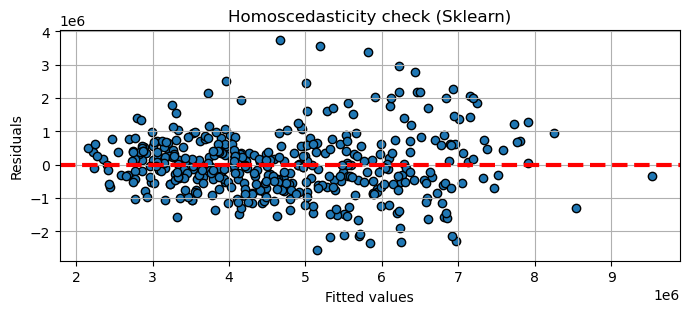

In [37]:
plt.figure(figsize=(8,3))

plt.scatter(y_train_pred, residuals, edgecolor='k')

plt.axhline(0, color='red', linestyle='--', lw=3)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity check (Sklearn)")
plt.grid(True)
plt.show()

There is prescence of heteroscedasticity where the variance increases significantly fr large fitted values.

**3. Normality**
- We want to confirm our assumption of normality amongst the residuals. If the residuals are non-normally distributed, confidence intervals can become too wide or too narrow, which leads to difficulty in estimating coefficients based on the minimisation of ordinary least squares.

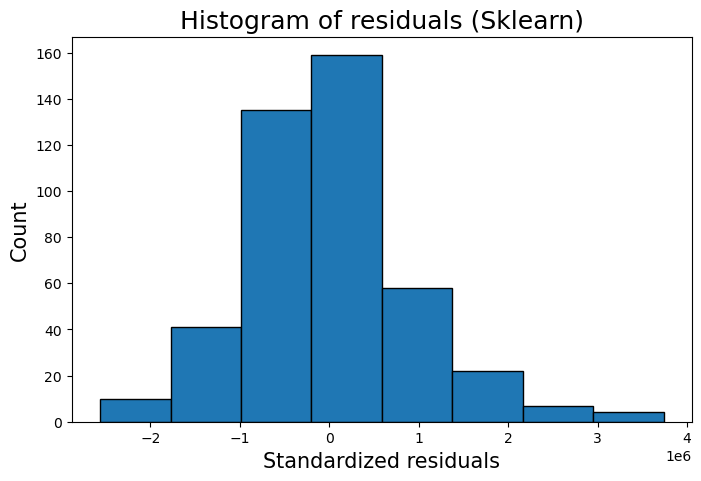

In [40]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=8, edgecolor='k')

plt.ylabel('Count', fontsize=15)
plt.xlabel('Standardized residuals', fontsize=15)
plt.title("Histogram of residuals (Sklearn)", fontsize=18)

plt.show()

- The data is approximately normal.

**4. Linearity**
- This was confirmed through the scatter plots where there was a linear relationship between the independent variables and price.

**5. Multicollinearity**
- From the correlation matrix there is no strong collinearity between the independent variables.

- The diagnostic checks suggest that the assumptions of linear regression are reasonably satisfied, although minor deviations may still exist.

- The Mean Squared Error (MSE) is relatively large, which indicates that there are still significant prediction errors. This may be due to outliers or the presence of non-linear relationships in the data.
- On average, the model’s predictions deviate from the actual house prices by approximately 1.1 million units, which suggests that while the model captures general trends, its prediction accuracy can still be improved.
- The model explains 6% of the variation in the housing prices.

# Objective 3: Evaluate the model using performance metrics like mean squared error (MSE) and R-squared.

In [92]:
# predict values
y_pred = lr.predict(X_test)

In [94]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"R Squared: {r2_score(y_test, y_pred)}")

Mean Squared Error: 1286637069521.3828
Root Mean Squared Error: 1134300.255453283
R Squared: 0.681516954237422


**Key Insights**
- Larger houses tend to have higher prices
- Bathrooms and number of stories significantly influence price
- Price variation is affected by multiple factors, not just size
- The dataset shows moderate predictability using linear methods

**This model can be useful in:**
- Real estate pricing tools to estimate property values
- Investment analysis for property developers
- Decision support systems for buyers and agents
- Market trend analysis to understand key price drivers

**Conclusion**

The Linear Regression model demonstrates moderate predictive performance, explaining a significant portion of house price variation (68%).

Key features such as area, bathrooms, and stories play an important role in determining property value. However, the model’s prediction error suggests that additional features or more advanced models could further improve accuracy.

Overall, this project provides a strong foundation for real estate price prediction and highlights the importance of data-driven decision-making.

# Objective 4: Experiment with multiple models (e.g., Decision Trees,Random Forest) and compare performance.

### Decision Tree

In [51]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [52]:
# test the perfrmance of the model
print(f"Mean Squared Error: {mean_squared_error(y_test, dt_pred)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, dt_pred)}")
print(f"R Squared: {r2_score(y_test, dt_pred)}")

Mean Squared Error: 2176543587155.9634
Root Mean Squared Error: 1475311.352615428
R Squared: 0.4612371683568083


- The MSE is very large compared to the linear model.
- On average the model predictions are off by 1.5 million units.
- The model explains 46% of the variation in the housing prices which is relatively low.
- The r squared is low meaning it is not capturing some underlying patterns.
- The RMSE and MSE is larger than the linear model.
- The model performs poorly compared to the linear model

### Random Forest

In [55]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [56]:
# test the perfrmance of the model
print(f"Mean Squared Error: {mean_squared_error(y_test, rf_pred)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test, rf_pred)}")
print(f"R Squared: {r2_score(y_test, rf_pred)}")

Mean Squared Error: 1503337932327.137
Root Mean Squared Error: 1226106.8192972164
R Squared: 0.6278766912288112


- The MSE is large compared to the linear model but less than Decision tree.
- On average the model predictions are off by 1.2 million units.
- The model explains 63% of the variation in the housing prices. This means that even though the model explains most of the data behaviour, it still des not fit perfectly.

### Conclusion

- The linear model supercedes the Decision Tree and Random Forest models